In [1]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("readr")
install.packages("dplyr")

library(sqldf)
library(ggplot2)
library(readr)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
customers <- read_csv("/content/customers.csv")
orders <- read_csv("/content/orders.csv")
deliveries <- read_csv("/content/deliveries.csv")
complaints <- read_csv("/content/complaints.csv")
drivers <- read_csv("/content/drivers.csv")
hubs <- read_csv("/content/hubs.csv")
incidents <- read_csv("/content/incidents.csv")
vehicles <- read_csv("/content/vehicles.csv")

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

In [3]:
head(customers)
head(orders)
head(deliveries)
head(complaints)

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


In [4]:
result1 <- sqldf("
SELECT delivery_status, COUNT(*) AS total
FROM deliveries
GROUP BY delivery_status
")

print(result1)

  delivery_status total
1         Delayed   202
2          Failed   132
3          OnTime   616


In [5]:
result2 <- sqldf("
SELECT complaint_type,
COUNT(*) AS total_complaints,
AVG(compensation_amount) AS avg_compensation,
AVG(resolution_days) AS avg_resolution_days
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

print(result2)

     complaint_type total_complaints avg_compensation avg_resolution_days
1             Delay              101         18.05149            7.257426
2      MissedPickup               64         22.59365            7.640625
3          AppIssue               53         19.61440            8.603774
4   DriverBehaviour               51         21.15348            8.156863
5 SupportExperience               20         17.12500            7.450000
6           Billing               16         23.87125            7.750000
7            Damage               15         23.98200           11.333333


In [6]:
result3 <- sqldf("
SELECT h.zone, COUNT(*) AS failed_count
FROM deliveries d
JOIN hubs h ON d.hub_id = h.hub_id
WHERE d.delivery_status = 'Failed'
GROUP BY h.zone
ORDER BY failed_count DESC
")

print(result3)

       zone failed_count
1   Central           49
2     North           17
3      West           16
4   Airport           15
5 Riverside           14
6      East           11
7     South           10


In [7]:
result4 <- sqldf("
SELECT d.delivery_status,
COUNT(c.complaint_id) AS total_complaints
FROM deliveries d
LEFT JOIN complaints c
ON d.order_id = c.order_id
GROUP BY d.delivery_status
")

print(result4)

  delivery_status total_complaints
1         Delayed               48
2          Failed               35
3          OnTime              149


In [8]:
result5 <- sqldf("
SELECT driver_id,
AVG(manual_route_override_count) AS avg_override
FROM deliveries
GROUP BY driver_id
ORDER BY avg_override DESC
LIMIT 10
")

print(result5)

   driver_id avg_override
1       D112     4.500000
2       D127     2.833333
3       D021     2.500000
4       D139     2.000000
5       D130     2.000000
6       D124     2.000000
7       D105     2.000000
8       D085     2.000000
9       D079     2.000000
10      D069     2.000000


In [9]:
result6 <- sqldf("
SELECT d.driver_id,
COUNT(dl.delivery_id) AS total_deliveries,
SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
ROUND(AVG(dl.customer_rating_post_delivery), 2) AS avg_rating
FROM drivers d
JOIN deliveries dl ON d.driver_id = dl.driver_id
GROUP BY d.driver_id
HAVING total_deliveries > 5
ORDER BY failed_deliveries DESC
LIMIT 10
")

print(result6)

   driver_id total_deliveries failed_deliveries avg_rating
1       D133               12                 4       3.42
2       D104                7                 4       3.93
3       D024                8                 4       3.44
4       D131                9                 3       3.66
5       D108               11                 3       4.41
6       D083                9                 3       3.91
7       D055               10                 3       3.81
8       D010                7                 3       4.15
9       D004                9                 3       3.51
10      D165                6                 2       2.98


In [10]:
result7 <- sqldf("
SELECT delivery_status,
AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY delivery_status
")

print(result7)

  delivery_status avg_cost
1         Delayed 13.13871
2          Failed 13.14795
3          OnTime 12.67805


In [11]:
result8 <- sqldf("
SELECT c.home_zone,
COUNT(cp.complaint_id) AS total_complaints,
AVG(c.loyalty_score) AS avg_loyalty
FROM customers c
LEFT JOIN complaints cp ON c.customer_id = cp.customer_id
GROUP BY c.home_zone
ORDER BY total_complaints DESC
")

print(result8)

   home_zone total_complaints avg_loyalty
1      SOUTH               33    60.43898
2  RiverSide               24    55.88929
3      North               24    60.17234
4    CENTRAL               24    58.14510
5       East               23    61.51373
6      north               21    60.55238
7  Riverside               21    60.56222
8       West               19    57.35319
9      NORTH               19    62.62432
10   Airport               19    57.32195
11       Ctr               18    63.80857
12     South               17    60.25333
13      EAST               17    56.20732
14   AIRPORT               15    60.62973
15   Central               14    62.24118
16      WEST               12    57.07333


In [12]:
result9 <- sqldf("
SELECT o.priority_level,
COUNT(o.order_id) AS total_orders,
SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_orders,
ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(o.order_id), 2) AS failure_rate
FROM orders o
LEFT JOIN deliveries d ON o.order_id = d.order_id
WHERE o.priority_level IN ('High', 'Critical')
GROUP BY o.priority_level
")

print(result9)

  priority_level total_orders failed_orders failure_rate
1       Critical           91             3         3.30
2           High          308            32        10.39


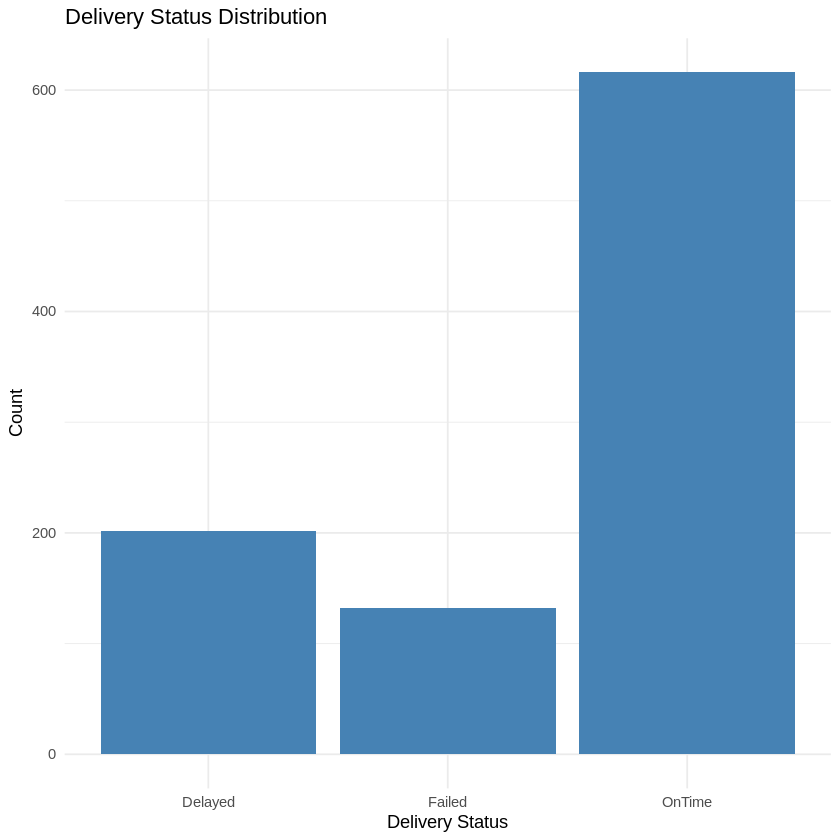

In [13]:
ggplot(deliveries,
       aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  theme_minimal() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Count"
  )

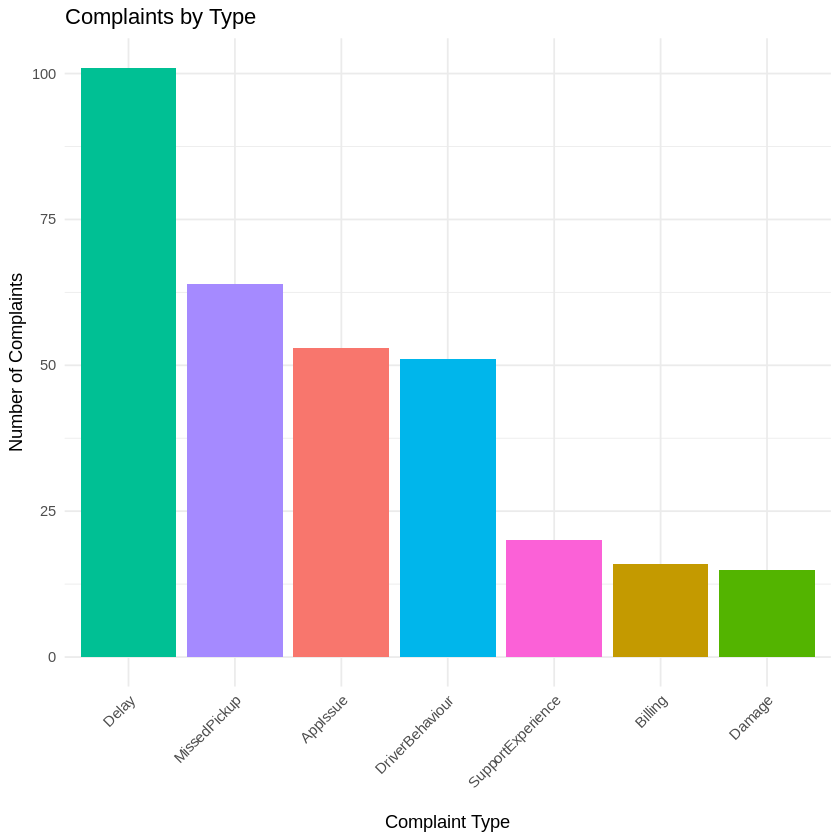

In [14]:
ggplot(result2,
       aes(x = reorder(complaint_type, -total_complaints),
           y = total_complaints,
           fill = complaint_type)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(
    title = "Complaints by Type",
    x = "Complaint Type",
    y = "Number of Complaints"
  ) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

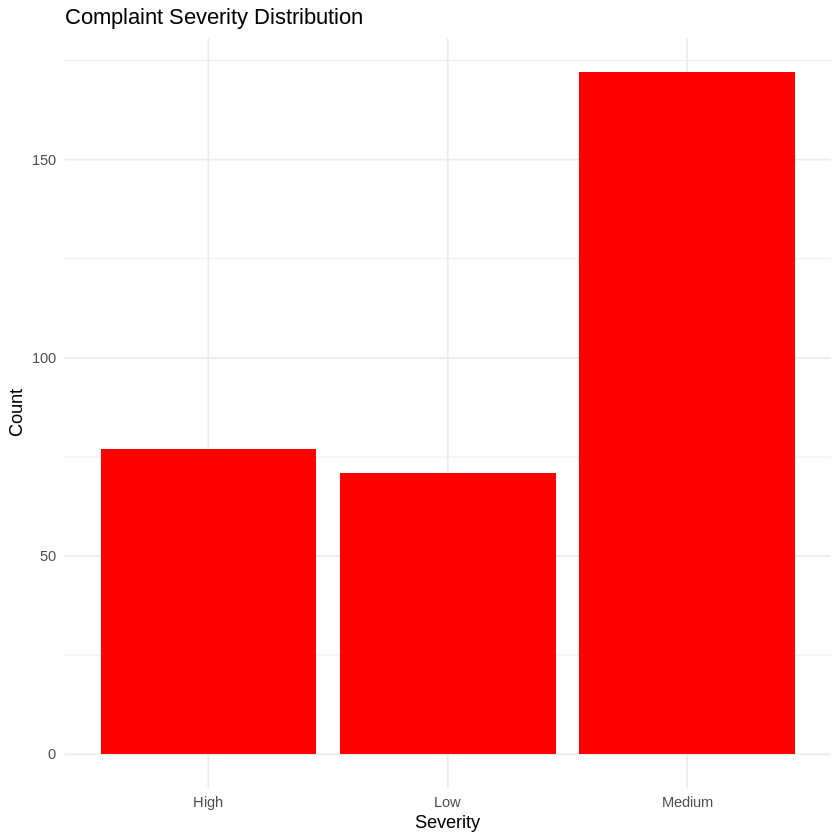

In [15]:
ggplot(complaints,
       aes(x = severity)) +
  geom_bar(fill = "red") +
  theme_minimal() +
  labs(
    title = "Complaint Severity Distribution",
    x = "Severity",
    y = "Count"
  )

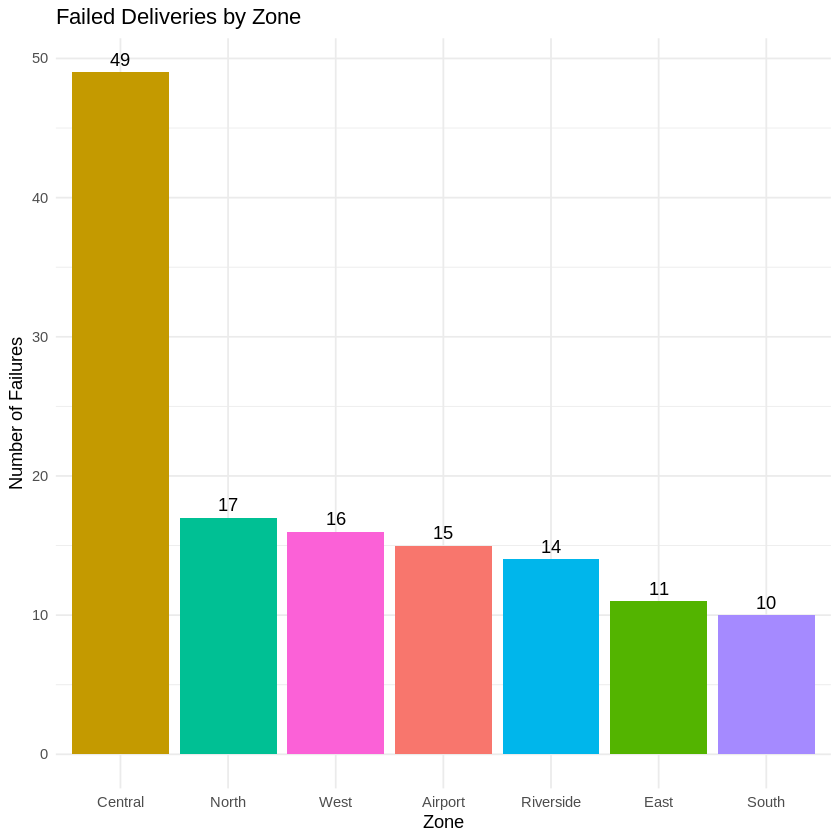

In [16]:
deliveries_with_zone <- merge(deliveries, hubs, by = "hub_id")

failed_zone <- as.data.frame(
  table(deliveries_with_zone$zone[deliveries_with_zone$delivery_status == "Failed"])
)

names(failed_zone) <- c("zone", "failed_count")

failed_zone <- failed_zone[order(-failed_zone$failed_count), ]

ggplot(failed_zone,
       aes(x = reorder(zone, -failed_count),
           y = failed_count,
           fill = zone)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = failed_count), vjust = -0.5) +
  labs(
    title = "Failed Deliveries by Zone",
    x = "Zone",
    y = "Number of Failures"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

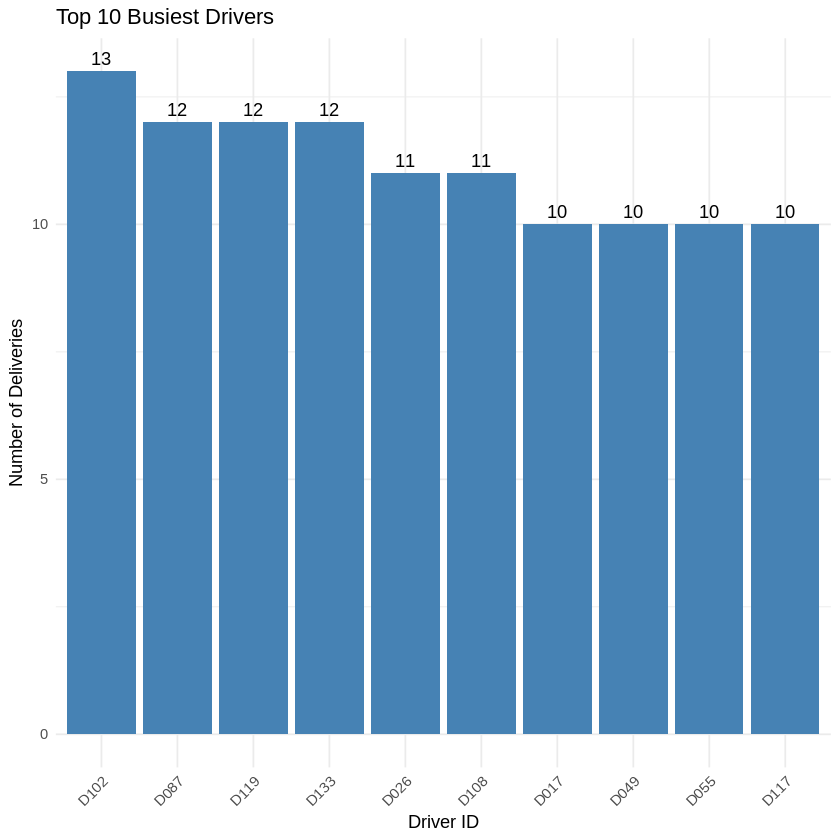

In [17]:
driver_workload <- as.data.frame(table(deliveries$driver_id))

names(driver_workload) <- c("driver_id", "delivery_count")

top_drivers <- head(
  driver_workload[order(-driver_workload$delivery_count), ],
  10
)

ggplot(top_drivers,
       aes(x = reorder(driver_id, -delivery_count),
           y = delivery_count)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = delivery_count), vjust = -0.5) +
  labs(
    title = "Top 10 Busiest Drivers",
    x = "Driver ID",
    y = "Number of Deliveries"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))